In [1]:
import os
import math
import pickle
import sys

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
project_root = "../../../.."

#Set error rate level for this analysis
error_rate_level = "typical" #"typical", "high", "stress"

#Load data if already processed; set to False to re-run data processing and overwrite cached results
LOAD_PROCESSED_DATA = True

In [3]:
if error_rate_level == "typical":
    indel_rate = "5e-06"
    sub_rate = "0.004"
elif error_rate_level == "high":
    indel_rate = "1.25e-05"
    sub_rate = "0.01"
elif error_rate_level == "stress":
    indel_rate = "3.75e-05"
    sub_rate = "0.03"
else:
    raise ValueError(f"Invalid error_rate_level: {error_rate_level}. Must be one of 'typical', 'high', 'stress'.")

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")
print(f"Error rates: indel={indel_rate}, substitution={sub_rate}")

# Human-readable error rate label for plot titles
indel_pct = float(indel_rate) * 2 * 100
sub_pct = float(sub_rate) * 100
error_rate_label = rf"indel rate={indel_pct}\%, substitution rate={sub_pct}\%"

read_lengths = [75, 100, 150, 300]

all_models = ["fgs_complete", "fgs_illumina_5", "fgs_illumina_10", "prodigal",
              "deep_cds_no_errors",
              "deep_cds_substitution", "deep_cds_errors"]

model_names = all_models
models_per_length = {length: all_models for length in read_lengths}

_script_name = "codon_level_read_length"
_cache_dir = (f"{project_root}/data/processed_data/report_results/"
             f"with_errors/{_script_name}/{indel_rate}i_{sub_rate}s")

Total test accessions: 215
Error rates: indel=5e-06, substitution=0.004


In [4]:
def get_full_cds(reads_dict):
    """Merge fragmented CDS annotations that belong to the same gene.

    When a CDS is split into multiple fragments (e.g. due to indel-induced
    frameshifts), this function reconnects them into a single CDS span using
    the cds_fragments_connection mapping. The merged CDS is labelled
    'disrupted_rf' and replaces the individual fragments. The original
    per-fragment [start, end, rf] entries are preserved as a 4th element
    so that codon-level evaluation can assign each sub-span its correct RF.

    Args:
        reads_dict: Dict mapping read names to dicts with 'cds_coords' (list of
            [start, end, rf] triplets) and 'cds_fragments_connection' (list of
            index groups indicating which fragments belong together).

    Returns:
        The modified reads_dict with fragmented CDS entries merged.
        Disrupted entries have the form [start, end, 'disrupted_rf', [[s1,e1,rf1], ...]].
    """
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []

        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]

                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]

                # Preserve original fragments with their RFs before merging
                original_fragments = [list(cds_coords[i]) for i in sorted(cds_frag_mapping)]

                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                indices_to_remove += cds_frag_mapping

                assert start_cds_frag < end_cds_frag, "Something went wrong processing indel-induced error in sequence!"
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf', original_fragments])
                reads_dict[read]['cds_coords'] = cds_coords

        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)

    return reads_dict


def split_by_rf(cds_coords):
    """Split CDS coordinate list into per-RF tuples, normalised to frame 0.

    Handles both normal entries (rf in '0'/'1'/'2') and disrupted_rf entries
    by expanding their stored original_fragments list. Each fragment is
    shifted to frame-0 coordinates (rf1 by -1, rf2 by -2) so that
    calculate_rates_for_rf receives a consistent coordinate space.

    Args:
        cds_coords: List of [start, end, rf] or [start, end, 'disrupted_rf',
            [[s1,e1,rf1], ...]] entries.

    Returns:
        Tuple of (rf0, rf1, rf2) where each is a list of (start, end) tuples
        in frame-0-normalised coordinates.
    """
    rf0, rf1, rf2 = [], [], []
    for c in cds_coords:
        if c[2] == 'disrupted_rf':
            for frag in c[3]:
                s, e, rf = frag[0], frag[1], frag[2]
                if rf == '0':
                    rf0.append((s, e))
                elif rf == '1':
                    rf1.append((s - 1, e - 1))
                elif rf == '2':
                    rf2.append((s - 2, e - 2))
        elif c[2] == '0':
            rf0.append((c[0], c[1]))
        elif c[2] == '1':
            rf1.append((c[0] - 1, c[1] - 1))
        elif c[2] == '2':
            rf2.append((c[0] - 2, c[1] - 2))
    return rf0, rf1, rf2


def calculate_rates_for_rf(cds_rf_testset, cds_rf_preds, codons_per_rf, seq_len):
    """Compute codon-level TP/FP/FN/TN for a single reading frame.

    Uses a boolean coverage array of length codons_per_rf * 3 (truncated to
    the nearest multiple of 3 to ensure clean codon counting). Coordinates
    are 1-based and assumed to already be shifted to reading frame 0.

    Args:
        cds_rf_testset: List of (start, end) tuples for ground-truth CDS in this RF.
        cds_rf_preds: List of (start, end) tuples for predicted CDS in this RF.
        codons_per_rf: Number of codons in this reading frame.
        seq_len: Original read length (used only to derive array length).

    Returns:
        Tuple of (TP, FP, FN, TN) codon counts.
    """
    seq_len_pred = codons_per_rf * 3  # truncate to nearest multiple of 3
    pred_covered = np.zeros(seq_len_pred, dtype=bool)
    actual_covered = np.zeros(seq_len_pred, dtype=bool)

    for start, end in cds_rf_preds:
        pred_covered[start - 1:end] = True

    for start, end in cds_rf_testset:
        actual_covered[start - 1:end] = True

    #Divide by 3 to convert from base pairs to codons, since each codon is 3 bp
    TP = int(np.sum(pred_covered & actual_covered) / 3)
    FP = int(np.sum(pred_covered & ~actual_covered) / 3)
    FN = int(np.sum(~pred_covered & actual_covered) / 3)
    TN = int(np.sum(~pred_covered & ~actual_covered) / 3)

    assert TP + FP + FN + TN == codons_per_rf

    return TP, FP, FN, TN


def matthews_corrcoef(TP, FP, FN, TN):
    """Compute Matthews Correlation Coefficient (MCC).

    Args:
        TP, FP, FN, TN: Confusion matrix counts.

    Returns:
        MCC in range [-1, 1]. Returns 0.0 if the denominator is zero.
    """
    numerator = (TP * TN) - (FP * FN)
    denominator = math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return numerator / denominator if denominator != 0 else 0.0


def calculate_performance_metrics_model(testset_dict, model_preds_dict, read_names_list,
                                        codons_per_rf, codons_total, seq_len):
    """Codon-level evaluation across all reads for a single model.

    For each read, splits CDS coordinates by reading frame (0, 1, 2) via
    split_by_rf(), which normalises rf1/rf2 to frame-0 coordinates and
    correctly expands disrupted_rf entries into their constituent fragments.

    Args:
        testset_dict: Ground-truth annotations dict.
        model_preds_dict: Model predictions dict.
        read_names_list: List of all read names to evaluate.
        codons_per_rf: Number of codons per reading frame (= (seq_len-3)//3).
        codons_total: Total codons across all 3 RFs (= codons_per_rf * 3).
        seq_len: Read length in bp.

    Returns:
        Dict with keys 'tp', 'fp', 'fn', 'tn', 'mcc', 'f1_score', 'precision', 'recall'.
    """
    TP = FP = FN = TN = 0

    for read in read_names_list:
        in_test = read in testset_dict
        in_pred = read in model_preds_dict

        if not in_test and not in_pred:
            TN += codons_total

        elif in_test and not in_pred:
            for rf in split_by_rf(testset_dict[read]['cds_coords']):
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf(rf, [], codons_per_rf, seq_len)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

        elif not in_test and in_pred:
            for rf in split_by_rf(model_preds_dict[read]['cds_coords']):
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf([], rf, codons_per_rf, seq_len)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

        else:
            for rf_t, rf_p in zip(split_by_rf(testset_dict[read]['cds_coords']),
                                  split_by_rf(model_preds_dict[read]['cds_coords'])):
                tp_, fp_, fn_, tn_ = calculate_rates_for_rf(rf_t, rf_p, codons_per_rf, seq_len)
                TP += tp_; FP += fp_; FN += fn_; TN += tn_

    mcc = matthews_corrcoef(TP, FP, FN, TN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'tp': TP, 'fp': FP, 'fn': FN, 'tn': TN,
        'mcc': round(mcc, 4), 'f1_score': round(f1, 4),
        'precision': round(precision, 4), 'recall': round(recall, 4)
    }

In [5]:
def load_testset(test_accession, data_type, project_root=project_root):
    """Load ground-truth testset dict and read names for a genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        data_type: Dataset identifier (e.g. 'with_errors_3.75e-05i_0.03s_300bp').
        project_root: Path to project root directory.

    Returns:
        Tuple of (read_names_list, testset_dict) where testset_dict has
        fragmented CDS merged via get_full_cds().
    """
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    """Load CDS predictions for a single model and genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        data_type: Dataset identifier (e.g. 'with_errors_3.75e-05i_0.03s_300bp').
        model_name: One of the 10 model keys defined in all_models.
        project_root: Path to project root directory.

    Returns:
        Predictions dict with fragmented CDS merged via get_full_cds().
    """
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_complete/{test_accession}.pkl",
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_5/{test_accession}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_10/{test_accession}.pkl",
        "deep_cds_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_substitution_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
       "deep_cds_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

# Evaluate performance across read lengths (codon-level, with errors)

In [7]:
if not LOAD_PROCESSED_DATA:
    # GC-content bins
    gc_bins = [0, 40, 50, 60, 100]
    gc_bin_labels = [r"$<$40\%", r"40--50\%", r"50--60\%", r"$>$60\%"]

    def get_gc_bin_label(gc_content):
        """Return the GC-content bin label for a given GC percentage value."""
        for i in range(len(gc_bins) - 1):
            if gc_bins[i] <= gc_content < gc_bins[i + 1]:
                return gc_bin_labels[i]
        return None

    def _init_length_gc_dict():
        """Initialize a nested dict of {read_length: {gc_label: {model: counts}}}."""
        return {
            length: {gc_label: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0} for model in model_names}
                     for gc_label in gc_bin_labels}
            for length in read_lengths
        }

    def _init_has_data_dict():
        """Initialize a nested dict of {read_length: {model: bool}} tracking data availability."""
        return {length: {model: False for model in model_names} for length in read_lengths}

    # Overall (excludes TT4 genomes for fair comparison)
    results_by_length = {
        length: {model: {'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0} for model in model_names}
        for length in read_lengths
    }
    results_by_length_gc = _init_length_gc_dict()
    has_data = _init_has_data_dict()

    # Per translation table
    results_by_length_gc_tt11 = _init_length_gc_dict()
    results_by_length_gc_tt4 = _init_length_gc_dict()
    has_data_tt11 = _init_has_data_dict()
    has_data_tt4 = _init_has_data_dict()

    # Per-genome metric lists for min/max error bars (excludes TT4)
    per_genome_metrics_list = {
        length: {model: {'mcc': [], 'f1_score': [], 'precision': [], 'recall': []}
                 for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"with_errors_{indel_rate}i_{sub_rate}s_{length}bp"
        seq_len = length
        codons_per_rf = (seq_len - 3) // 3
        codons_total = codons_per_rf * 3
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (codons_per_rf={codons_per_rf}, codons_total={codons_total})...")

        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                continue

            # Determine GC bin and translation table for this accession
            gc_label = None
            tt = None
            if test_accession in all_genomes:
                gc_label = get_gc_bin_label(all_genomes[test_accession]['gc_content'])
                tt = all_genomes[test_accession]['translation_table']

            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                    metrics = calculate_performance_metrics_model(
                        testset_dict, preds, read_names_list, codons_per_rf, codons_total, seq_len)
                    tp = metrics['tp']
                    fp = metrics['fp']
                    fn = metrics['fn']
                    tn = metrics['tn']

                    # Overall aggregation (exclude TT4 for fair comparison)
                    if tt != 4:
                        results_by_length[length][model]['tp'] += tp
                        results_by_length[length][model]['fp'] += fp
                        results_by_length[length][model]['fn'] += fn
                        results_by_length[length][model]['tn'] += tn
                        has_data[length][model] = True

                        per_genome_metrics_list[length][model]['mcc'].append(metrics['mcc'])
                        per_genome_metrics_list[length][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[length][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[length][model]['recall'].append(metrics['recall'])

                        if gc_label is not None:
                            results_by_length_gc[length][gc_label][model]['tp'] += tp
                            results_by_length_gc[length][gc_label][model]['fp'] += fp
                            results_by_length_gc[length][gc_label][model]['fn'] += fn
                            results_by_length_gc[length][gc_label][model]['tn'] += tn

                    # Per-TT aggregation
                    if gc_label is not None:
                        if tt == 11:
                            results_by_length_gc_tt11[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt11[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt11[length][gc_label][model]['fn'] += fn
                            results_by_length_gc_tt11[length][gc_label][model]['tn'] += tn
                            has_data_tt11[length][model] = True
                        elif tt == 4:
                            results_by_length_gc_tt4[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt4[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt4[length][gc_label][model]['fn'] += fn
                            results_by_length_gc_tt4[length][gc_label][model]['tn'] += tn
                            has_data_tt4[length][model] = True
                except Exception as e:
                    continue

else:

    print(f"Loading pre-computed results from:\n  {_cache_dir}")
    with open(os.path.join(_cache_dir, "results_by_length.pkl"), "rb") as f:
        results_by_length = pickle.load(f)
    with open(os.path.join(_cache_dir, "results_by_length_gc.pkl"), "rb") as f:
        results_by_length_gc = pickle.load(f)
    with open(os.path.join(_cache_dir, "results_by_length_gc_tt11.pkl"), "rb") as f:
        results_by_length_gc_tt11 = pickle.load(f)
    with open(os.path.join(_cache_dir, "results_by_length_gc_tt4.pkl"), "rb") as f:
        results_by_length_gc_tt4 = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
        has_data = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data_tt11.pkl"), "rb") as f:
        has_data_tt11 = pickle.load(f)
    with open(os.path.join(_cache_dir, "has_data_tt4.pkl"), "rb") as f:
        has_data_tt4 = pickle.load(f)
    with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
        per_genome_metrics_list = pickle.load(f)

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/with_errors/codon_level_read_length/5e-06i_0.004s


In [8]:
if not LOAD_PROCESSED_DATA:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_length": results_by_length,
        "results_by_length_gc": results_by_length_gc,
        "results_by_length_gc_tt11": results_by_length_gc_tt11,
        "results_by_length_gc_tt4": results_by_length_gc_tt4,
        "has_data": has_data,
        "has_data_tt11": has_data_tt11,
        "has_data_tt4": has_data_tt4,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for _name, _obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{_name}.pkl"), "wb") as f:
            pickle.dump(_obj, f)
    print(f"Results saved to {_cache_dir}")

In [10]:
# Compute aggregated metrics from raw counts
metrics_keys = ['mcc', 'f1_score', 'precision', 'recall']
aggregated_metrics = {model: {k: [] for k in metrics_keys} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            for k in metrics_keys:
                aggregated_metrics[model][k].append(np.nan)
            continue

        tp = results_by_length[length][model]['tp']
        fp = results_by_length[length][model]['fp']
        fn = results_by_length[length][model]['fn']
        tn = results_by_length[length][model]['tn']

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        mcc = matthews_corrcoef(tp, fp, fn, tn)

        aggregated_metrics[model]['mcc'].append(mcc)
        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Compute per-genome min/max for error bars
per_genome_min_max = {
    model: {metric: {'min': [], 'max': []} for metric in metrics_keys}
    for model in model_names
}
for length in read_lengths:
    for model in model_names:
        for metric in metrics_keys:
            vals = per_genome_metrics_list[length][model][metric]
            if vals:
                per_genome_min_max[model][metric]['min'].append(min(vals))
                per_genome_min_max[model][metric]['max'].append(max(vals))
            else:
                per_genome_min_max[model][metric]['min'].append(np.nan)
                per_genome_min_max[model][metric]['max'].append(np.nan)

# Plot performance as a function of read length

In [12]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS


def plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, metric_name, ylabel):
    """Plot per-genome metric distributions as grouped boxplots across read lengths.

    Args:
        per_genome_metrics_list: Dict of {length: {model: {metric_name: [values_per_genome]}}}.
        read_lengths: List of read lengths for the x-axis.
        metric_name: Key into metrics (e.g. 'f1_score', 'mcc', 'precision', 'recall').
        ylabel: Y-axis label and part of the plot title.
    """
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_name] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    matplotlib.rcParams['text.usetex'] = False
    fig, ax = plt.subplots(figsize=(11, 7))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])

    ax.set_xlabel('Read Length (bp)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{ylabel} by Read Length (codon-level, per genome, TT11)\n{error_rate_label}', fontsize=14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0.4, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.09), loc='upper center', ncol=4)

    plt.tight_layout()
    # plt.savefig(f"codon_level_{metric_name}_by_read_length_boxplot_{error_rate_label}.svg", dpi=500)
    plt.show()

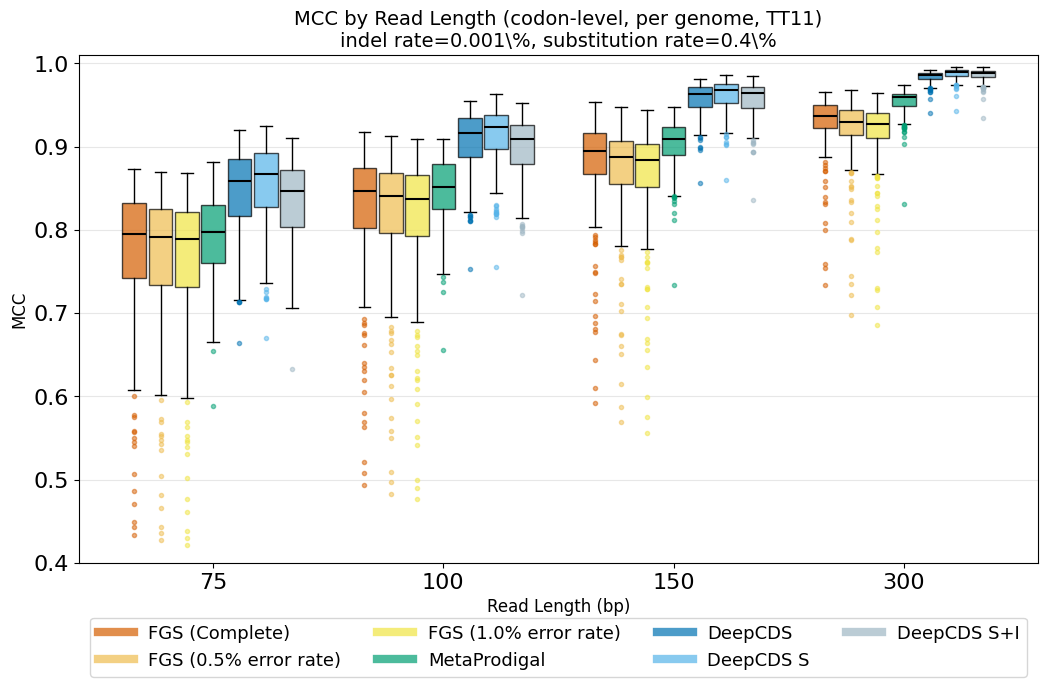

In [13]:
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'f1_score', 'F1 Score')
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'mcc', 'MCC')
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'precision', 'Precision')
#plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'recall', 'Sensitivity')

In [14]:
# Generate LaTeX table with 4 metric sections (MCC, F1, Sensitivity, Precision)
# Rows: model names grouped by metric; Columns: read lengths
# Best score per read length is bolded

metrics_order = [
    ('mcc',       'MCC'),
    ('f1_score',  'F1 Score'),
    ('recall',    'Sensitivity'),
    ('precision', 'Precision'),
]

col_fmt = 'l' + 'c' * len(read_lengths)
header_cols = ' & '.join([f'{l}bp' for l in read_lengths])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f' & {header_cols} \\\\')

for sec_idx, (metric_key, metric_label) in enumerate(metrics_order):
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\')
    lines.append(r'\midrule')

    # Find best value per read length for this metric
    best_per_length = []
    for i in range(len(read_lengths)):
        col_vals = [aggregated_metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_length.append(max(valid) if valid else None)

    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i, length in enumerate(read_lengths):
            v = aggregated_metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_length[i] is not None and v == best_per_length[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        row = f'{display} & ' + ' & '.join(vals) + r' \\'
        lines.append(row)

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION. Aggregated codon-level performance metrics across all test genomes for each model, stratified by read length. Best score per read length is bolded. TT4 genomes are excluded for fair comparison.}')
lines.append(r'\label{tab:codon_read_length_with_errors}')
lines.append(r'\end{table}')

print('\n'.join(lines))

\begin{table}[ht]
\centering
\begin{tabular}{lcccc}
\toprule
 & 75bp & 100bp & 150bp & 300bp \\
\midrule
\multicolumn{5}{l}{\textbf{MCC}} \\
\midrule
FGS (Complete) & 0.787 & 0.838 & 0.888 & 0.933 \\
FGS (0.5% error rate) & 0.783 & 0.831 & 0.879 & 0.925 \\
FGS (1.0% error rate) & 0.780 & 0.828 & 0.876 & 0.921 \\
MetaProdigal & 0.792 & 0.846 & 0.903 & 0.955 \\
DeepCDS & 0.855 & 0.913 & 0.960 & 0.985 \\
DeepCDS S & \textbf{0.863} & \textbf{0.919} & \textbf{0.964} & \textbf{0.988} \\
DeepCDS S+I & 0.843 & 0.905 & 0.960 & 0.987 \\
\midrule
\multicolumn{5}{l}{\textbf{F1 Score}} \\
\midrule
FGS (Complete) & 0.814 & 0.859 & 0.902 & 0.942 \\
FGS (0.5% error rate) & 0.811 & 0.853 & 0.895 & 0.935 \\
FGS (1.0% error rate) & 0.808 & 0.850 & 0.892 & 0.932 \\
MetaProdigal & 0.819 & 0.866 & 0.916 & 0.961 \\
DeepCDS & 0.874 & 0.924 & 0.965 & 0.987 \\
DeepCDS S & \textbf{0.880} & \textbf{0.930} & \textbf{0.969} & \textbf{0.990} \\
DeepCDS S+I & 0.862 & 0.917 & 0.965 & 0.989 \\
\midrule
\multicolumn{5}{